<a href="https://colab.research.google.com/github/PedroConst/EQE-358-Metodos-Numericos/blob/main/Lab/Lab_04_Coluna_de_Destila%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 04 – Coluna de Destilação**

## Objetivos
- Introduzir colunas de destilação industriais
- Definir funções em Python
- Resolver um sistema de equações não-lineares em Python usando o Método de Newton-Raphson
- Utilizar um método de continuação homotópica

---

## Contexto

As colunas de destilação são equipamentos fundamentais na engenharia de processos, utilizados para separar misturas líquidas com base nas diferenças de volatilidade entre seus componentes. Nessas colunas, a separação ocorre por meio de sucessivas etapas de equilíbrio entre vapor e líquido ao longo de pratos ou recheios internos, permitindo que os componentes mais voláteis se concentrem na corrente de topo enquanto os menos voláteis se acumulam no fundo da coluna. Esse processo é amplamente empregado em diversas indústrias, especialmente no refino de petróleo, na petroquímica, na produção de solventes e na indústria química em geral. O projeto e a operação de colunas de destilação envolvem a análise integrada de equilíbrio de fases, balanços de massa e energia, transferência de calor e hidrodinâmica interna, tornando-as um dos exemplos mais importantes de operações de separação na engenharia química.


Refinaria de Duque de Caxias (REDUC)

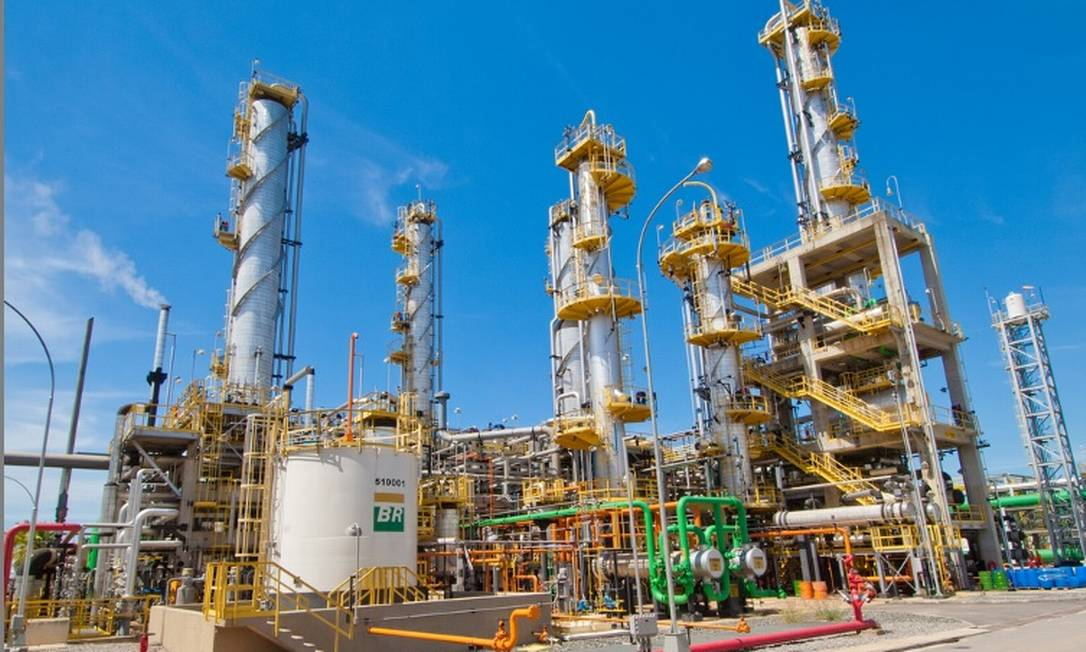

## **Modelo Matemático**

Lei de Raoult:

$$
x_nP_1^{sat}=y_nP
\tag{1}
$$

$$
\left(1-x_n\right)P_2^{sat}=\left(1-y_n\right)P
\tag{2}
$$

Equação de Antoine:

$$
\log_{10}{P_i^{sat}}=A_i-\frac{B_i}{T_n+C_i}
\tag{3}
$$

Linha de Operação (Balanço de Massa):

$$
y_{n+1}=\left(\frac{R}{1+R}\right)x_n+\left(\frac{1}{1+R}\right)x_D
\tag{4}
$$


##**🔹 Passo 1 – Importar bibliotecas**

In [ ]:
import ...
import ...
from numpy.linalg import norm, solve

##**🔹 Passo 2 – Inserir Dados do Problema**

In [ ]:
# Parâmetros especificados no enunciado do problema (linha de operação)
N = ...
Rd = ...
xD = ...

# Especificações de Pressão
P = ...  # mmHg

# Coeficientes de Antoine
# BENZENO
A1 = ...
B1 = ...
C1 = ...
# TOLUENO
A2 = ...
B2 = ...
C2 = ...

##**🔹 Passo 3 – Definir Função Antoine**

In [ ]:
def antoineBT(...):
    global A1,B1,C1,A2,B2,C2
    # Calcular as duas pressões de saturação
    P1 = ...  # mmHg
    P2 = ...  # mmHg

    return P1, P2

##**🔹 Passo 4 – Definir Função Residual**

In [ ]:
def computeR(xn,yn,Tn,P):
    # Calcular as duas pressões de saturação
    P1, P2 = ...

    # Calcular as funções f1 e f2
    f1 = ...
    f2 = ...

    # Retornar um vetor coluna
    R = ... # Transposta
    return R

In [ ]:
# Testar com xn=0.7, yn=0.7, Tn=90 e P = 760  # mmHg
...

##**🔹 Passo 5 – Definir Função Jacobiano**

In [ ]:
def computeJ(xn,yn,Tn):
    global A1,B1,C1,A2,B2,C2

    # O Jacobiano será uma matriz 2x2
    J = ...

    # Calcular as duas pressões de saturação
    P1, P2 = ...

    J[0, 0] = ...    # df1/dxn
    J[0, 1] = ...    # df1/dTn
    J[1, 0] = ...    # df2/dxn
    J[1, 1] = ...    # df2/dTn
    return J

In [ ]:
# Testar com xn=0.7, yn=0.7 e Tn=90
...

##**🔹 Passo 6 – Definir Newton Raphson**

In [ ]:
def NewtonRaphson(yn,P,xn,Tn):
    # Os valores de xn e Tn são chutes iniciais.
    R = ...
    tol = ...

    # Cada iteração verifica a norma de dx em relação à tolerância.
    while norm(R) > tol:

        J = ...    # Calcular J e R para o chute atual.
        R = ...

        dx = - solve(J, R)              # Calcular a distância para o próximo chute.

        xn = xn + dx[0]                 # Atualizar xn and Tn.
        Tn = Tn + dx[1]

    return xn, Tn

##**🔹 Passo 7 – Resolver um Estágio**

In [ ]:
# Fração molar de benzeno no vapor
yn = ...

#Chute Inicial
xn = ...    # Fração molar de benzeno no líquido
Tn = ...    # Temperatura no estágio da coluna

# Newton-Raphson
xn, Tn = ...

# Resultados
print(f'xn = {xn:.4f} \t Tn = {Tn:.2f}°C')

##**🔹 Passo 8 – Utilizar Método de Continuação**

In [ ]:
# Composição do destilado
y1 = xD

# Initial guesses
x1 = ...
T1 = ...

xn = x1
yn = y1
Tn = T1

# Matriz vazia para guardar os resultados de cada estágio
xM = ...

# Varrer um loop por todos os estágios da coluna
print("Coluna de Retificação - Newton-Raphson")
print("===========================================")
print(" k\t xn\t yn\t Tn\t")
print("===========================================")

for k in range(...,...):
    # Realizar iteração NR para o estágio k
    xn, Tn = ...

    print("%2d\t %.4f\t %.4f\t %.4f" % (k, xn, yn, Tn))
    # Adicionar à matriz resultados
    xM[k-1, :] = ...

    # Atualizar yn de acordo com a linha de operação da coluna
    yn = ...
print("==========================================")

##**🔹 Passo 9 – Visualizar Resultados**

In [ ]:
# Plotar Gráficos
n = ...   # Vetor com número do estágio

plt.figure(figsize=[15,5])

plt.subplot(1,3,1)
plt.plot(..., ...,'-ob')
plt.title('...')
plt.xlabel('...')
plt.ylabel('...')

plt.subplot(1,3,2)
plt.plot(..., ...,'-ob')
plt.title('...')
plt.xlabel('...')
plt.ylabel('...')

plt.subplot(1,3,3)
plt.plot(..., ...,'-ob')
plt.title('...')
plt.xlabel('...')
plt.ylabel('...')

plt.show()